In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## QUESTION 1) 6 pts

### a) Import the two pics provided

In [2]:
SPIDER_PATH       = 'spider.jpeg'
SPIDER_BLACK_PATH = 'spiderblack.jpg'

SPIDER_BGR        = cv2.imread(SPIDER_PATH)
SPIDER_BLACK_BGR  = cv2.imread(SPIDER_BLACK_PATH)

SPIDER_RGB        = cv2.cvtColor(SPIDER_BGR,       cv2.COLOR_BGR2RGB)
SPIDER_BLACK_RGB  = cv2.cvtColor(SPIDER_BLACK_BGR, cv2.COLOR_BGR2RGB)

(168, 300, 3)

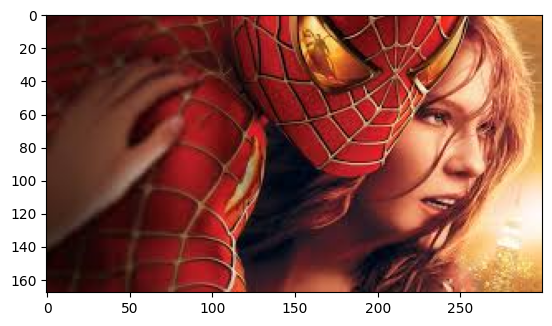

In [3]:
display(SPIDER_RGB.shape)
plt.imshow(SPIDER_RGB)

(800, 1200, 3)

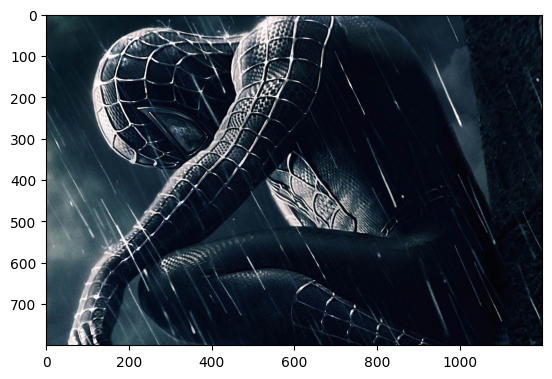

In [4]:
display(SPIDER_BLACK_RGB.shape)
plt.imshow(SPIDER_BLACK_RGB)

### b) Resize the small pic to (200,120)

In [5]:
small_img_rgb = cv2.resize(SPIDER_RGB, (200, 120))

(120, 200, 3)

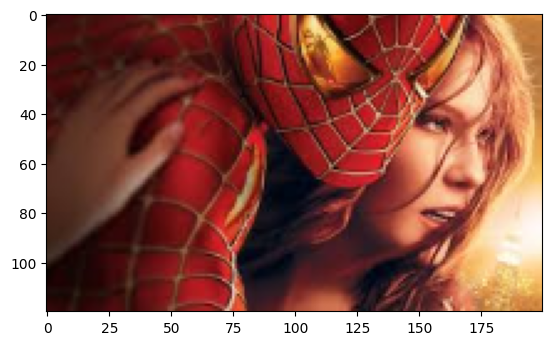

In [6]:
display(small_img_rgb.shape)
plt.imshow(small_img_rgb)

### c) Show these pics as shown below, but fix the colors

## QUESTION 2 - 6.0 pts
### Hint, follow the images below


### a) Show the code to provide the picture below

### b) As you are going to realize, small picture covered a little space of the big picture. Explain what        you have to do to fix it up.

#### a.1) Copy and paste

In [7]:
# Offsets and fall/run
## Corresponding the size of the small image
large_img = SPIDER_BLACK_RGB.copy()

y_offset = 390
y_fall   = y_offset + small_img_rgb.shape[0] 

x_offset = 0
x_run    = x_offset + small_img_rgb.shape[1]

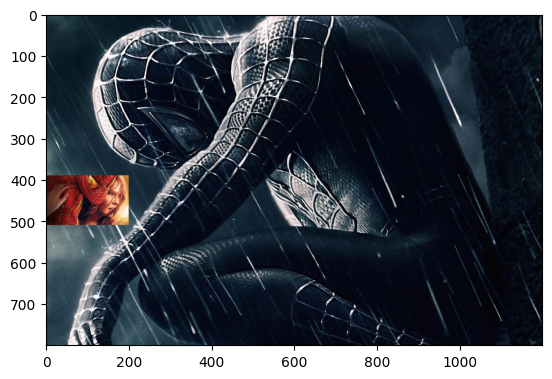

In [8]:
large_img[y_offset : y_fall,
          x_offset : x_run] = small_img_rgb
plt.imshow(large_img)

#### a.2) Region of Interest (ROI)

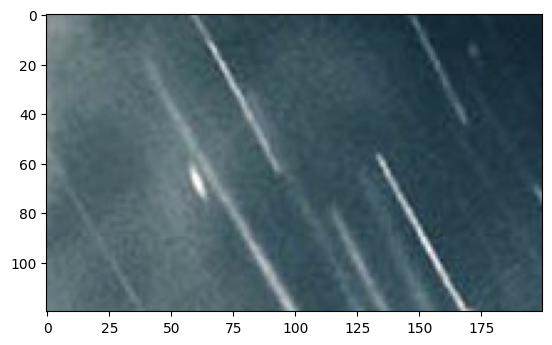

In [9]:
# Reset large image
large_img = SPIDER_BLACK_RGB.copy()

# Creating an ROI of the same size of the foreground image (smaller image that will go on top)
rows, cols, channels = small_img_rgb.shape

roi_img = large_img[y_offset : y_fall,
                x_offset : x_run]

plt.imshow(roi_img)

In [10]:
roi_img.shape

(120, 200, 3)

#### a.3) Mask and Inverse mask

In [11]:
# Mask
small_img_gray = cv2.cvtColor(small_img_rgb,
                              cv2.COLOR_RGB2GRAY)

In [12]:
small_img_gray.shape

(120, 200)

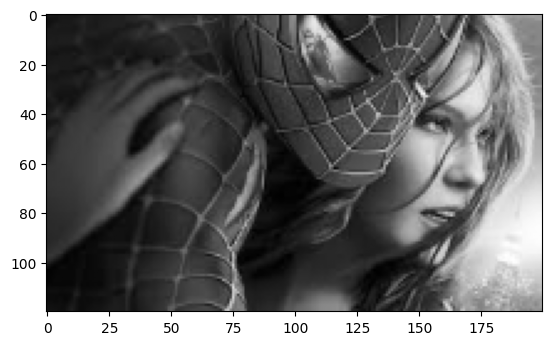

In [13]:
plt.imshow(small_img_gray,
           cmap='gray')

In [14]:
# Inverse mask
small_img_gray_inverse = cv2.bitwise_not(small_img_gray)

In [15]:
small_img_gray_inverse.shape

(120, 200)

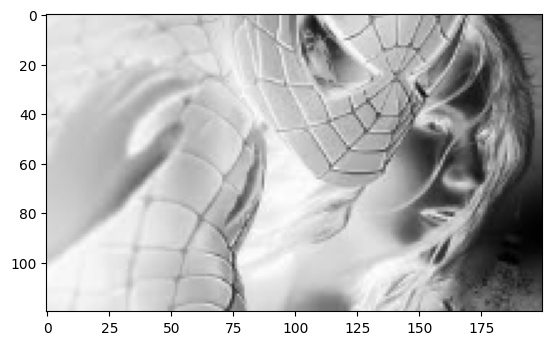

In [16]:
plt.imshow(small_img_gray_inverse,
           cmap='gray')

#### a.4) Three channels

##### a.4.1) Background

In [17]:
white_background = np.full(small_img_rgb.shape,
                           255,
                           dtype = np.uint8)

In [18]:
small_img_background = cv2.bitwise_or(white_background,
                           white_background,
                           mask = small_img_gray_inverse)

In [19]:
small_img_background.shape

(120, 200, 3)

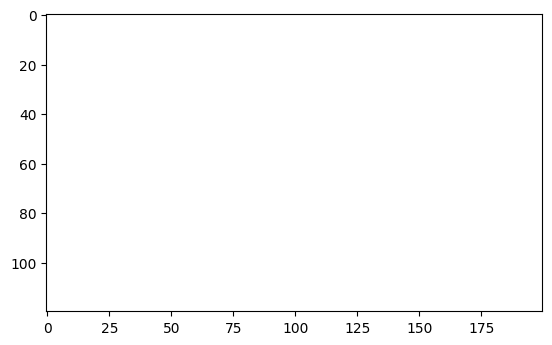

In [20]:
plt.imshow(small_img_background)

##### a.4.1) Foreground

In [21]:
foreground_img = cv2.bitwise_or(small_img_rgb,
                                small_img_rgb,
                                mask = small_img_gray)


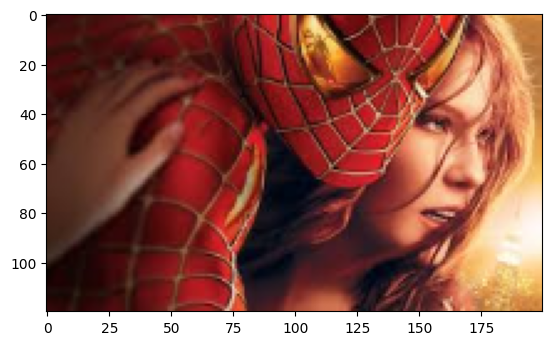

In [22]:
plt.imshow(foreground_img)

#### a.5) Blend

In [23]:
final_roi = cv2.bitwise_or(roi_img,
                           foreground_img)

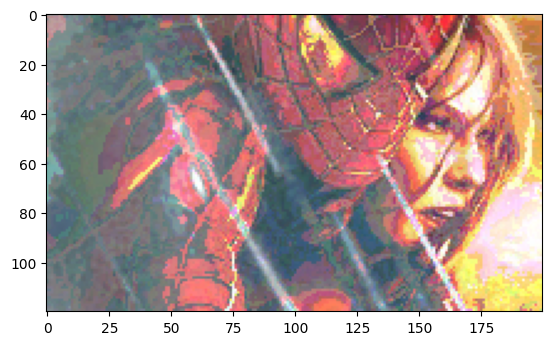

In [24]:
plt.imshow(final_roi)

#### a.6) Paste back in the larger image

In [25]:
small_img_rgb.shape[1]

200

In [26]:
x_offset

0

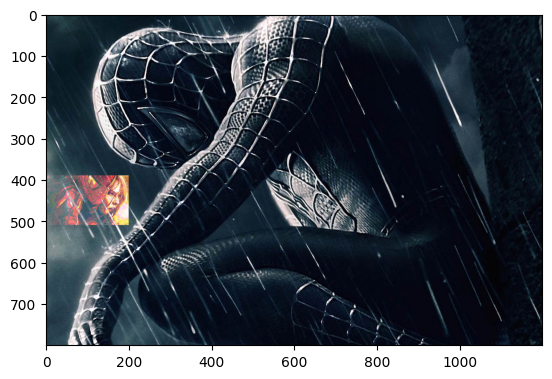

In [27]:
# Reset large image
large_img = SPIDER_BLACK_RGB.copy()

# Paste back in the larger image
large_img[y_offset : y_fall,
          x_offset : x_run] = final_roi

plt.imshow(large_img)

## QUESTION 3 6.0 pts

- What can you see when comparing the first blending with this blending_pasting?
- Explain how could you get this final picture which has got the little pic in and getting able to see the rain drops and the Spiderman with Mary Jane at the **same time**

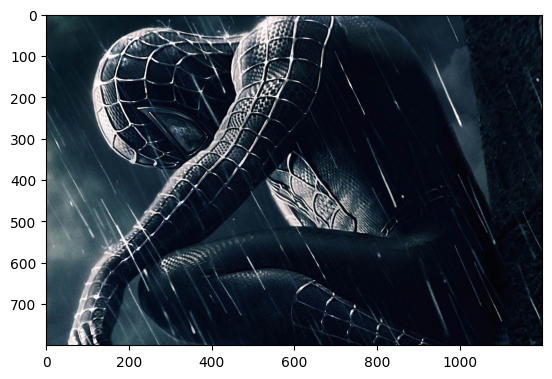

In [28]:
spirderman_black_rgb = SPIDER_BLACK_RGB.copy()
plt.imshow(spirderman_black_rgb)

#### a) Threshold testing

In [29]:
THRESHOLD = 127
MAXVALUE = 255

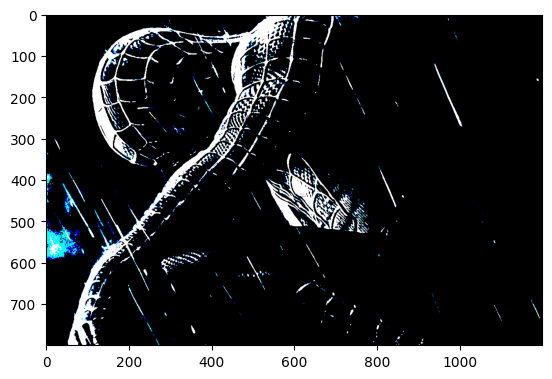

In [30]:
ret, thresh1 = cv2.threshold(spirderman_black_rgb,
                             THRESHOLD,
                             MAXVALUE,
                             cv2.THRESH_BINARY)

plt.imshow(thresh1,
           cmap='gray')

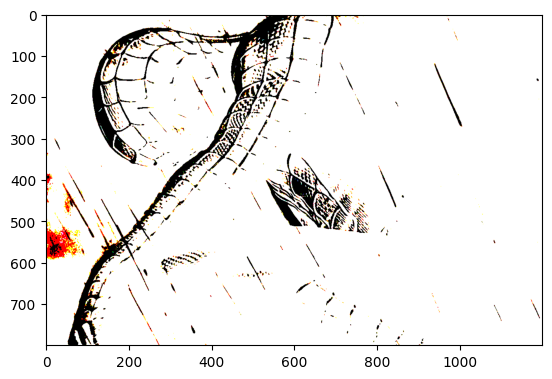

In [31]:
ret, thresh2 = cv2.threshold(spirderman_black_rgb,
                            THRESHOLD,
                            MAXVALUE,
                            cv2.THRESH_BINARY_INV)

plt.imshow(thresh2,
           cmap='gray')

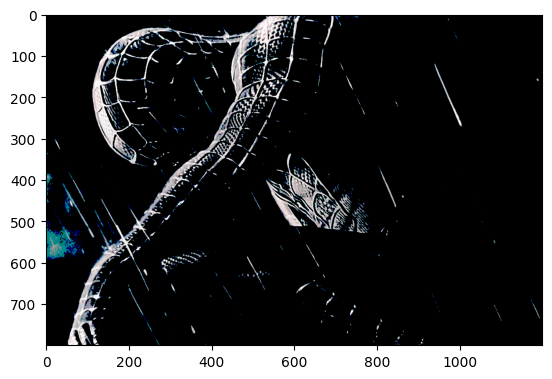

In [32]:
ret, thresh3 = cv2.threshold(spirderman_black_rgb,
                             THRESHOLD,
                             MAXVALUE,
                             cv2.THRESH_TOZERO)

plt.imshow(thresh3,
           cmap='gray')

#### b) Gray scale

In [33]:
# Gray scale reading
img = cv2.imread("spiderblack.jpg", 0)

In [34]:
def show_pic(img):
    fig = plt.figure(figsize=(15, 15))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap='gray')

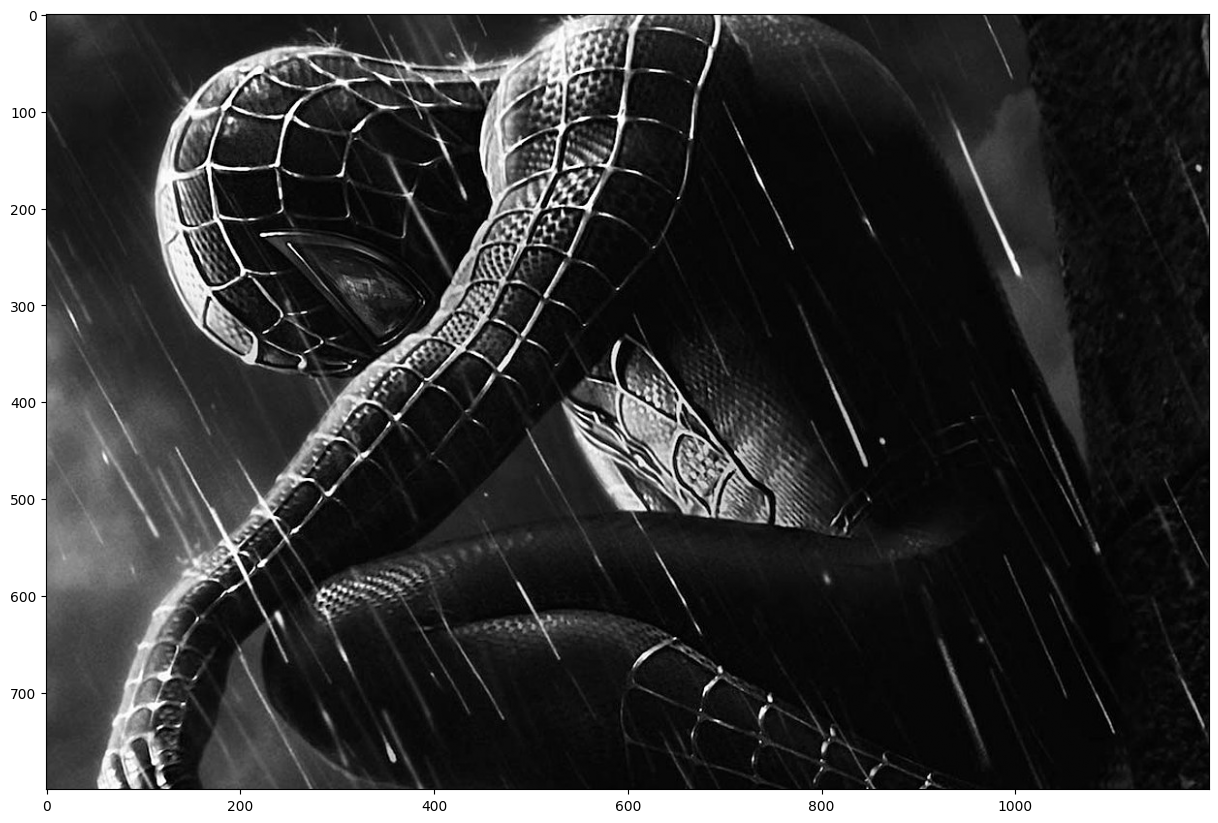

In [35]:
show_pic(img)

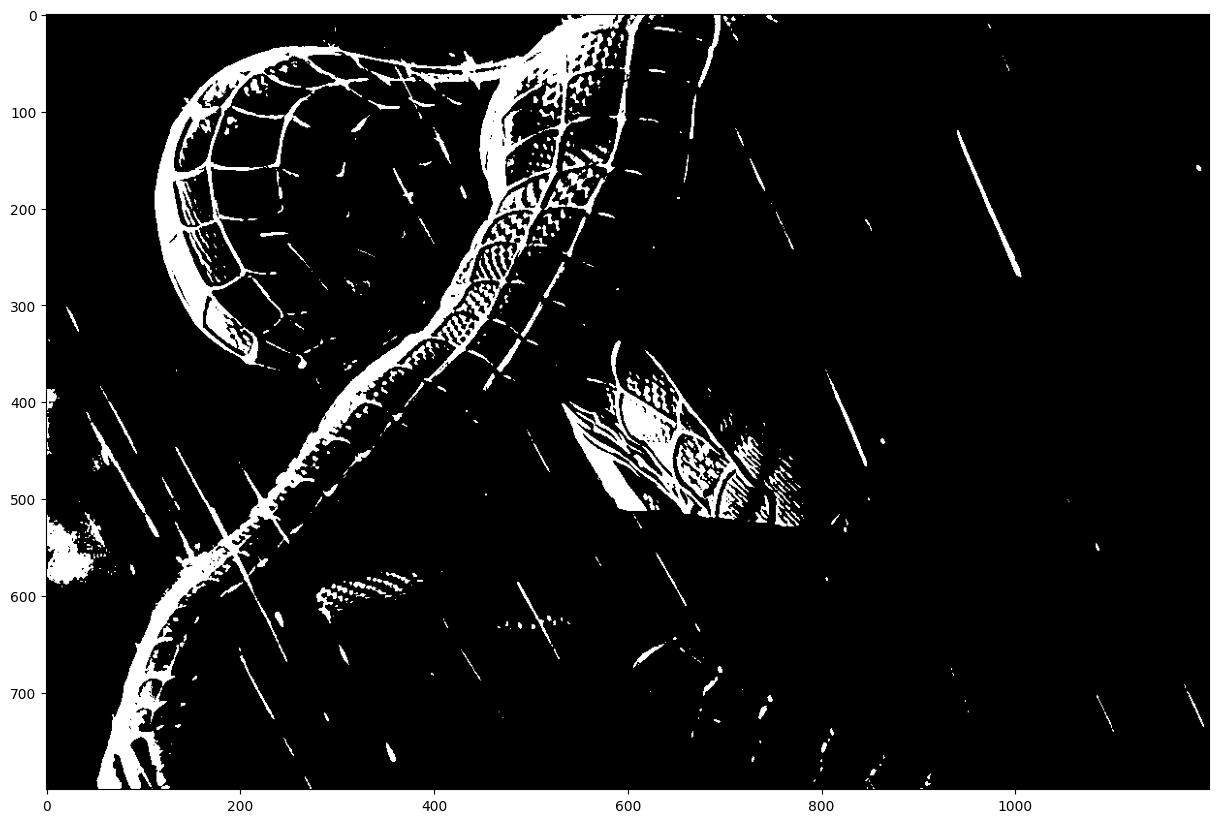

In [36]:
ret, th1 = cv2.threshold(img,
                         THRESHOLD,
                         MAXVALUE,
                         cv2.THRESH_BINARY)
show_pic(th1)

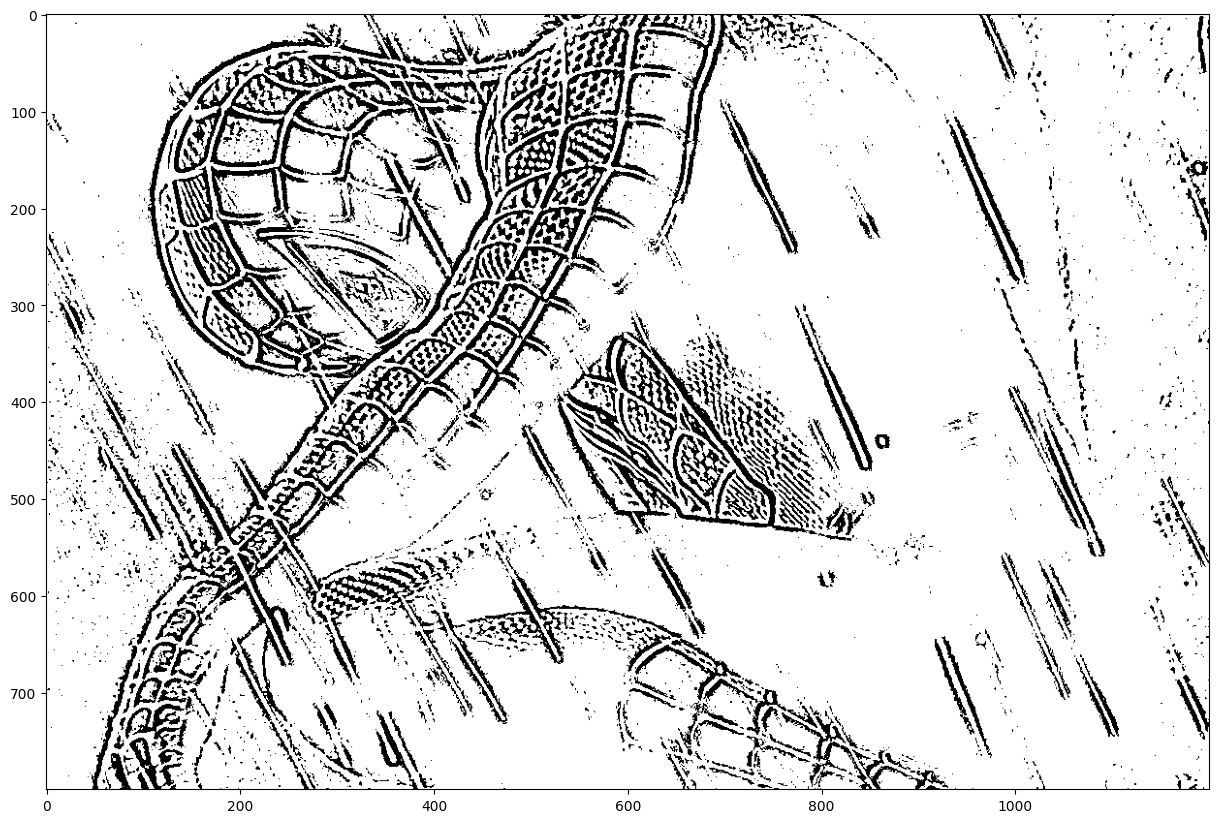

In [37]:
th2 = cv2.adaptiveThreshold(img,
                            MAXVALUE,
                            cv2.ADAPTIVE_THRESH_MEAN_C,
                            cv2.THRESH_BINARY,
                            11,
                            8) # Play around with these last 2 numbers
show_pic(th2)

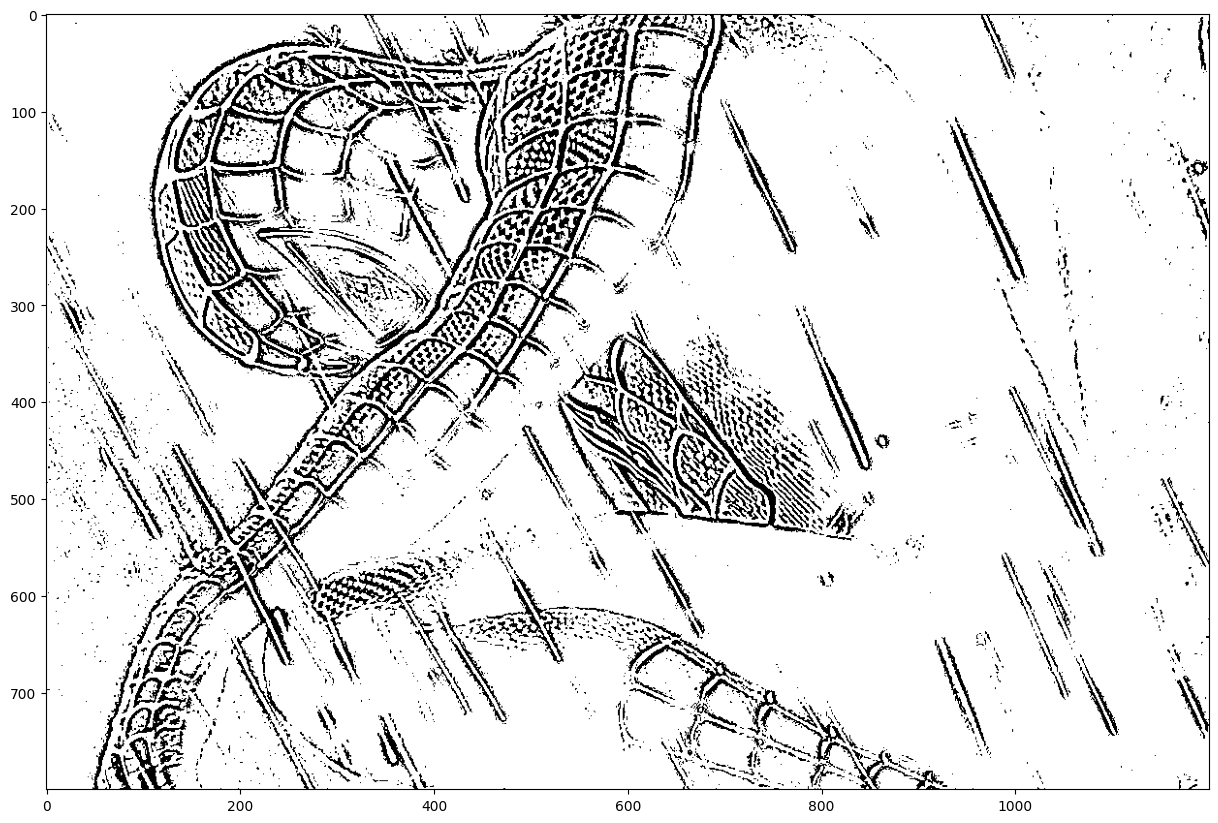

In [38]:
th3 = cv2.adaptiveThreshold(img,
                            MAXVALUE,
                            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                            cv2.THRESH_BINARY,
                            15,
                            8)
show_pic(th3)

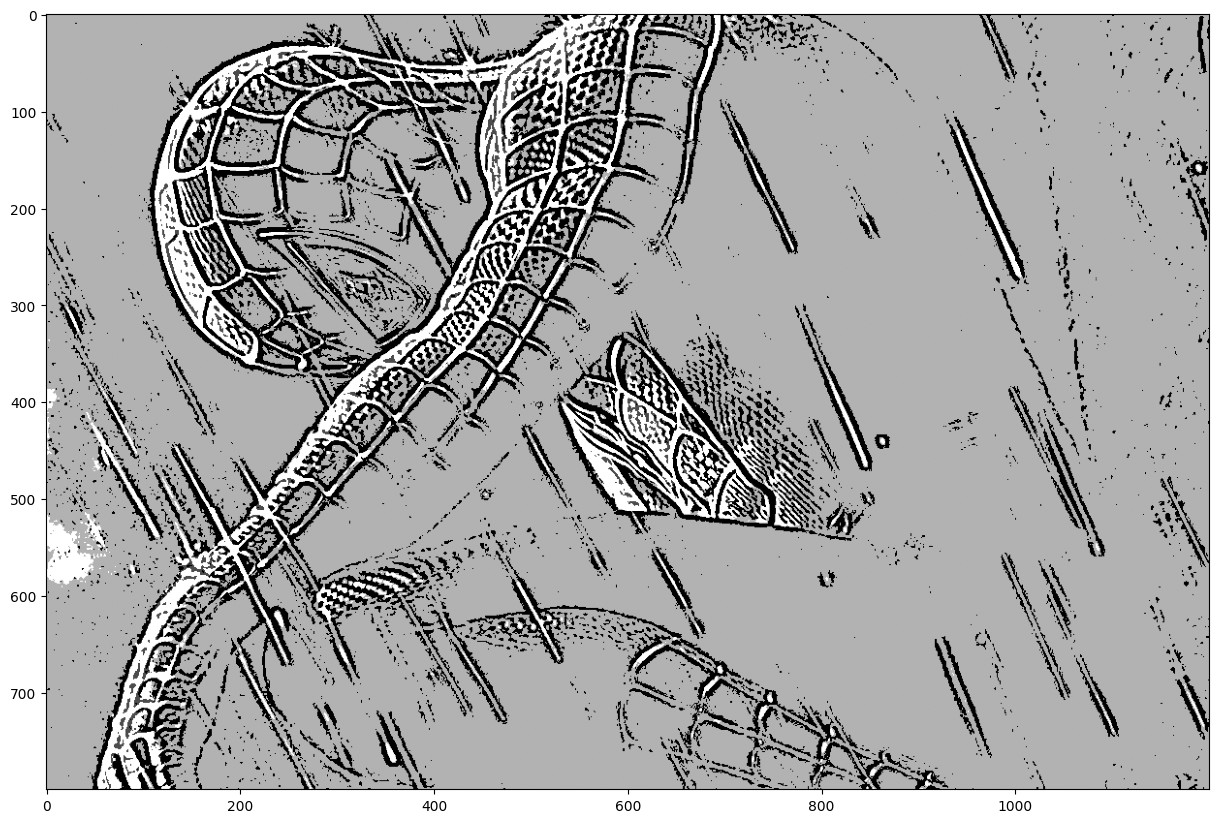

In [39]:
blended = cv2.addWeighted(src1 = th1,
                          alpha = 0.3,
                          src2 = th2,
                          beta = 0.7,
                          gamma = 0)
show_pic(blended)

## QUESTION 4 - 7.0  pts

# By observing each picture above and taking into
# account image_thresholding, explaing the last
# function cv2.addWeighted() and the rule of the
# parameter alpha, beta and gamma